
 PERFORMANS KARŞILAŞTIRMA TABLOSU 
╒══════════════════════════╤════════════════════════╤════════════════════════╤═══════════════════════╕
│ Algoritma                │   Bulunan Yol Uzunluğu │   Ziyaret Edilen Hücre │   Çalışma Süresi (ms) │
╞══════════════════════════╪════════════════════════╪════════════════════════╪═══════════════════════╡
│ BFS (Genişlik Öncelikli) │                     19 │                     52 │                0.0552 │
├──────────────────────────┼────────────────────────┼────────────────────────┼───────────────────────┤
│ DFS (Derinlik Öncelikli) │                     21 │                     65 │                0.0627 │
╘══════════════════════════╧════════════════════════╧════════════════════════╧═══════════════════════╛


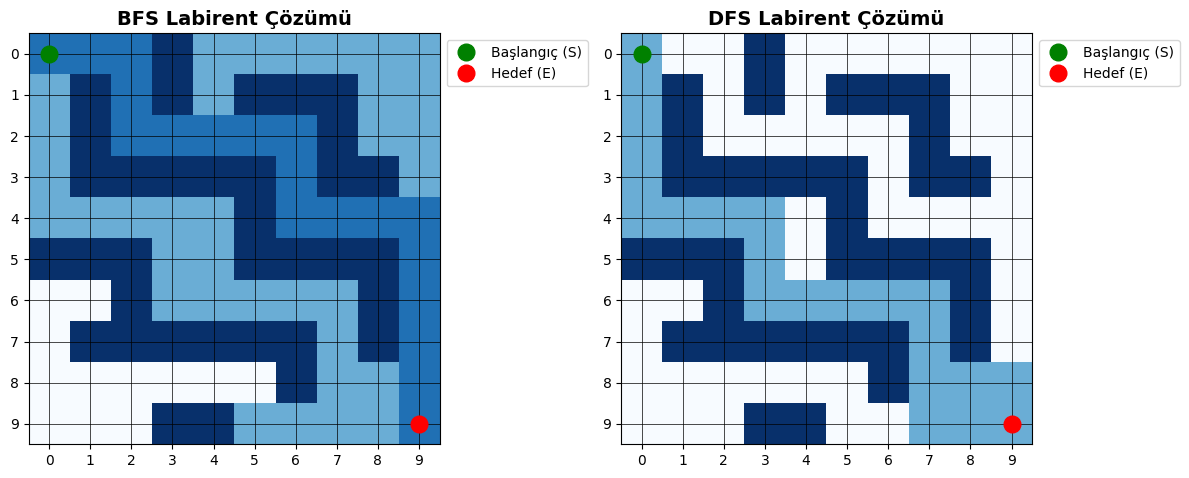

In [2]:
import time
from collections import deque
from tabulate import tabulate
import matplotlib.pyplot as plt  # Görselleştirme için eklendi
import numpy as np               # Matris işlemleri için eklendi

# 1. SABİTLER VE YÖNLER
DUVAR = 1
YOL = 0
YONLER = [(0, 1), (1, 0), (0, -1), (-1, 0)]  # Sağ, Aşağı, Sol, Yukarı

# 2. 10x10 ENGELLİ OYUN HARİTASI (GRID) 
ORNEK_GRID = [
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 1, 0, 0, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0, 0, 0]
]

BASLANGIC = (0, 0)
BITIS = (9, 9)

# 3. YARDIMCI FONKSİYONLAR 
def komsu_getir(grid, satir, sutun):
    komsular = []
    for ds, dk in YONLER:
        yeni_s = satir + ds                  #ds satır değişimi
        yeni_k = sutun + dk                  #dk sütun değişimi 
        if 0 <= yeni_s < len(grid) and 0 <= yeni_k < len(grid[0]):
            if grid[yeni_s][yeni_k] != DUVAR:
                komsular.append((yeni_s, yeni_k))
    return komsular

def yolu_geri_izle(ebeveyn, baslangic, bitis):
    yol = []
    mevcut = bitis
    while mevcut is not None:
        yol.append(mevcut)
        mevcut = ebeveyn.get(mevcut)
    yol.reverse()
    return yol

# MATPLOTLIB GÖRSELLEŞTİRME FONKSİYONU 
def sonuclari_gorsellestir(grid, bfs_ziyaret, bfs_yol, dfs_ziyaret, dfs_yol):
    """BFS ve DFS sonuçlarını matplotlib ile yan yana iki grafik olarak çizer."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    def grafik_ciz(ax, ziyaret, yol, baslik):
        # Arka plan matrisi oluşturuldu (0: Boş, 1: Duvar, 2: Ziyaret Edildi, 3: Yol)
        matris = np.array(grid, dtype=float)
        
        for h in ziyaret:
            matris[h[0], h[1]] = 0.5  # Ziyaret edilenler gri/mavi ton yapıldı
        for h in yol:
            matris[h[0], h[1]] = 0.75 # Bulunan yol farklı tonda yapıldı
            
        # Renk haritası (cmap) kullanarak grid çizdirildi
        ax.imshow(matris, cmap="Blues", origin="upper")
        
        # Başlangıç ve Bitiş noktaları işaretlendi
        ax.plot(BASLANGIC[1], BASLANGIC[0], "go", markersize=12, label="Başlangıç (S)")
        ax.plot(BITIS[1], BITIS[0], "ro", markersize=12, label="Hedef (E)")
        
        # Grid çizgileri ve numaraları ayarlandı
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))
        ax.grid(color="black", linestyle="-", linewidth=0.5)
        ax.set_title(baslik, fontsize=14, fontweight='bold')
        ax.legend(loc="upper left", bbox_to_anchor=(1, 1))

    # Sol Grafik: BFS
    grafik_ciz(ax1, bfs_ziyaret, bfs_yol, "BFS Labirent Çözümü")
    # Sağ Grafik: DFS
    grafik_ciz(ax2, dfs_ziyaret, dfs_yol, "DFS Labirent Çözümü")
    
    plt.tight_layout()
    plt.show()

# 4. ARAMA ALGORİTMALARI 
def bfs(grid, baslangic, bitis):
    kronometre_basla = time.perf_counter()
    ziyaret_edildi = set([baslangic])
    ebeveyn = {baslangic: None}
    kuyruk = deque([baslangic])
    ziyaret_sayisi = 0
    
    while kuyruk:
        mevcut = kuyruk.popleft()
        ziyaret_sayisi += 1
        if mevcut == bitis:
            sure = (time.perf_counter() - kronometre_basla) * 1000
            return ziyaret_edildi, yolu_geri_izle(ebeveyn, baslangic, bitis), ziyaret_sayisi, sure
            
        for komsu in komsu_getir(grid, mevcut[0], mevcut[1]):
            if komsu not in ziyaret_edildi:
                ziyaret_edildi.add(komsu)
                ebeveyn[komsu] = mevcut
                kuyruk.append(komsu)
                
    return ziyaret_edildi, [], ziyaret_sayisi, (time.perf_counter() - kronometre_basla) * 1000

def dfs(grid, baslangic, bitis):
    kronometre_basla = time.perf_counter()
    ziyaret_edildi = set()
    ebeveyn = {baslangic: None}
    yigit = [baslangic]
    ziyaret_sayisi = 0
    
    while yigit:
        mevcut = yigit.pop()
        if mevcut not in ziyaret_edildi:
            ziyaret_edildi.add(mevcut)
            ziyaret_sayisi += 1
            if mevcut == bitis:
                sure = (time.perf_counter() - kronometre_basla) * 1000
                return ziyaret_edildi, yolu_geri_izle(ebeveyn, baslangic, bitis), ziyaret_sayisi, sure
                
            for komsu in komsu_getir(grid, mevcut[0], mevcut[1]):
                if komsu not in ziyaret_edildi:
                    ebeveyn[komsu] = mevcut
                    yigit.append(komsu)
                    
    return ziyaret_edildi, [], ziyaret_sayisi, (time.perf_counter() - kronometre_basla) * 1000

# 5. ÇALIŞTIRMA VE RAPORLAMA
if __name__ == "__main__":
    # Algoritmalar çalıştırıldı
    bfs_sit, bfs_yol, bfs_sayi, bfs_sure = bfs(ORNEK_GRID, BASLANGIC, BITIS)
    dfs_sit, dfs_yol, dfs_sayi, dfs_sure = dfs(ORNEK_GRID, BASLANGIC, BITIS)
    
    # 1. Performans Tablosu Terminale Basıldı
    tablo_verisi = [
        ["Algoritma", "Bulunan Yol Uzunluğu", "Ziyaret Edilen Hücre", "Çalışma Süresi (ms)"],
        ["BFS (Genişlik Öncelikli)", len(bfs_yol), bfs_sayi, f"{bfs_sure:.4f}"],
        ["DFS (Derinlik Öncelikli)", len(dfs_yol), dfs_sayi, f"{dfs_sure:.4f}"]
    ]
    print(f"\n{'='*40}\n PERFORMANS KARŞILAŞTIRMA TABLOSU \n{'='*40}")
    print(tabulate(tablo_verisi, headers="firstrow", tablefmt="fancy_grid"))
    
    # 2. Matplotlib ile Haritalar Ekrana Çizdirildi
    sonuclari_gorsellestir(ORNEK_GRID, bfs_sit, bfs_yol, dfs_sit, dfs_yol)


 BÜYÜK GRİD (25x25) PERFORMANS TESTİ 
╒════════════════╤════════════════════════╤════════════════════════╤═══════════════════════╕
│ Algoritma      │   Bulunan Yol Uzunluğu │   Ziyaret Edilen Hücre │   Çalışma Süresi (ms) │
╞════════════════╪════════════════════════╪════════════════════════╪═══════════════════════╡
│ BFS (Genişlik) │                     49 │                    487 │                0.4255 │
├────────────────┼────────────────────────┼────────────────────────┼───────────────────────┤
│ DFS (Derinlik) │                    281 │                    440 │                0.426  │
╘════════════════╧════════════════════════╧════════════════════════╧═══════════════════════╛


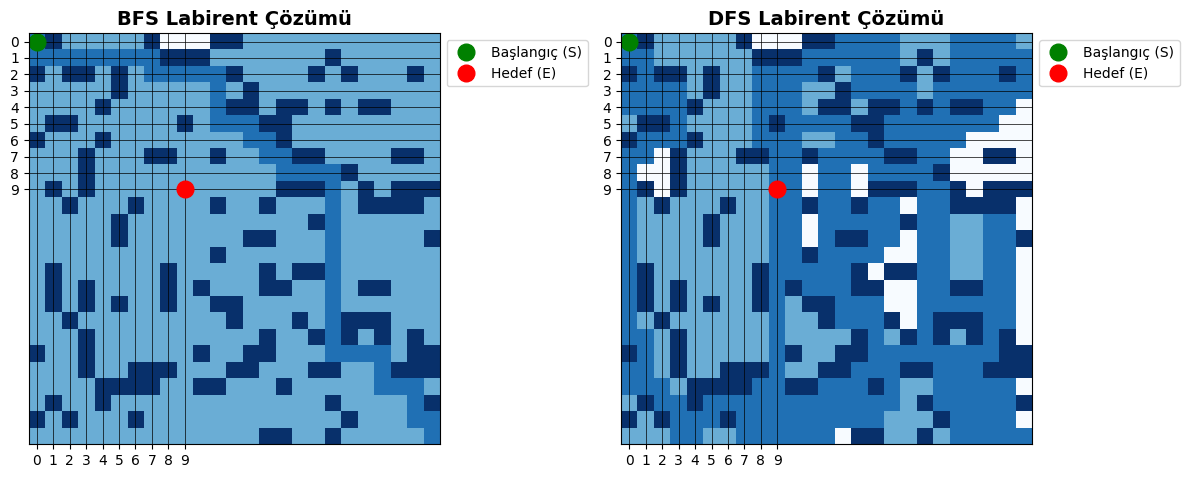

In [4]:
# BÜYÜK GRİD İLE KARŞILAŞTIRMA (EK KOD)
print("\n" + "="*40 + "\n BÜYÜK GRİD (25x25) PERFORMANS TESTİ \n" + "="*40)

# 25x25 boyutunda rastgele %20 engel (DUVAR) içeren büyük bir grid oluşturuldu.
np.random.seed(42)  # Her çalıştırmada aynı haritanın gelmesi için eklendi.
BUYUK_GRID = np.random.choice([YOL, DUVAR], size=(25, 25), p=[0.8, 0.2]).tolist()

# Başlangıç ve bitiş noktalarını garantiye alındı (Yol olmalılar)
BUYUK_GRID[0][0] = YOL
BUYUK_GRID[24][24] = YOL

BASLANGIC_B = (0, 0)
BITIS_B = (24, 24)

# Algoritmalar büyük gridde çalıştırıldı
b_bfs_sit, b_bfs_yol, b_bfs_sayi, b_bfs_sure = bfs(BUYUK_GRID, BASLANGIC_B, BITIS_B)
b_dfs_sit, b_dfs_yol, b_dfs_sayi, b_dfs_sure = dfs(BUYUK_GRID, BASLANGIC_B, BITIS_B)

# Sonuçları Tabloya Döküldü
buyuk_tablo_verisi = [
    ["Algoritma", "Bulunan Yol Uzunluğu", "Ziyaret Edilen Hücre", "Çalışma Süresi (ms)"],
    ["BFS (Genişlik)", len(b_bfs_yol) if b_bfs_yol else "Yol Yok", b_bfs_sayi, f"{b_bfs_sure:.4f}"],
    ["DFS (Derinlik)", len(b_dfs_yol) if b_dfs_yol else "Yol Yok", b_dfs_sayi, f"{b_dfs_sure:.4f}"]
]

print(tabulate(buyuk_tablo_verisi, headers="firstrow", tablefmt="fancy_grid"))

sonuclari_gorsellestir(BUYUK_GRID, b_bfs_sit, b_bfs_yol, b_dfs_sit, b_dfs_yol)
